# Module 06: Outlier Detection & Handling (Practice Problems)

এই নোটবুকে আউটলায়ার সনাক্তকরণ (Z-Score, IQR) এবং তা হ্যান্ডেল করার বিভিন্ন মেথডগুলো প্র্যাকটিস করার জন্য প্রশ্নগুলো সাজানো হয়েছে।

### 📌 শুরু করার আগে: প্রয়োজনীয় লাইব্রেরি ইমপোর্ট

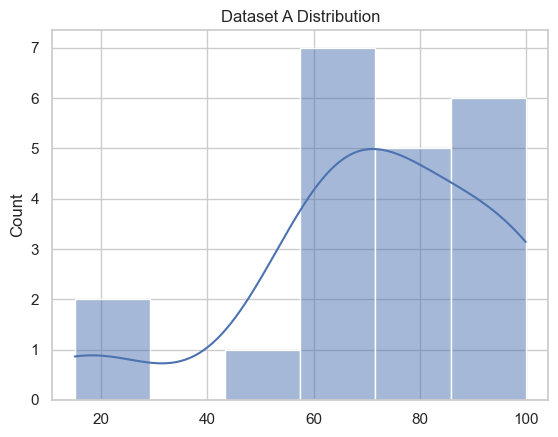

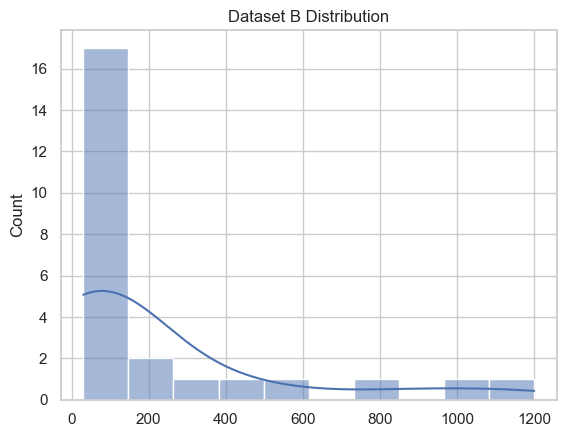

Dataset B Outliers count: 4
Outliers: [ 500  800 1000 1200]


In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")

## 📝 Problem 1: Z-Score Method (Normal Data)

**Dataset (Age of students in a class):**  
`[18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70]`

**Tasks:**
* Calculate the mean and standard deviation of Age.  
* Compute Z-Score for each value.  
* Identify outliers using |Z| > 3 conditions.  
* Remove those outliers and show the new dataset length.

In [47]:
# ১. ডাটা তৈরি
data1 = [18, 19, 20, 20, 21, 21, 22, 22, 23, 24, 25, 26, 27, 28, 30, 32, 35, 40, 45, 70]
df1 = pd.DataFrame(data1, columns=['Age'])

# ২. Mean এবং Std বের করা
mean_age = df1['Age'].mean()
std_age = df1['Age'].std()
print(f"Mean: {mean_age}, Std: {std_age}")

# ৩. Z-Score ক্যালকুলেট (মডিউলের নিয়মে ম্যানুয়াল ফর্মুলা)
df1['Z_Score'] = (df1['Age'] - mean_age) / std_age

# ৪. Outlier বের করা (abs(Z) > 3)
outliers = df1[abs(df1['Z_Score']) > 3]
print("Outliers:")
display(outliers)

# ৫. Outlier রিমুভ করে নতুন ডাটা
clean_df1 = df1[abs(df1['Z_Score']) <= 3]
print(f"Original Length: {len(df1)}, New Length: {len(clean_df1)}")

Mean: 28.4, Std: 12.132600710482482
Outliers:


,Age,Z_Score
19,70,3.428778


Original Length: 20, New Length: 19


## 📝 Problem 2: IQR Method (Skewed Data)

**Dataset (Monthly salaries in thousand BDT):**  
`[25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]`

**Tasks:**
* Calculate Q1 (25th percentile) and Q3 (75th percentile).  
* Find IQR = Q3 - Q1.  
* Calculate lower bound and upper bound.  
* Identify outliers.  
* Cap (clip) the outliers to the bounds instead of deleting them.  
* Show min and max after capping.

In [48]:
# Code for Problem 2
data2 = [25, 28, 30, 32, 32, 33, 35, 35, 36, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 120, 150, 200, 250, 500]
s2 = pd.Series(data2)

# ১. Q1 এবং Q3 বের করা
Q1 = s2.quantile(0.25)
Q3 = s2.quantile(0.75)

# ২. IQR বের করা
IQR = Q3 - Q1

# ৩. লিমিট বের করা
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Lower Limit: {lower_limit}, Upper Limit: {upper_limit}")

# ৪. Outlier গুলো খুঁজে বের করা
outliers_iqr = s2[(s2 < lower_limit) | (s2 > upper_limit)]
print("Outliers:", outliers_iqr.values)

# ৫. Capping (ক্লিপিং) করা - মডিউলের নিয়মে clip()
s2_capped = s2.clip(lower_limit, upper_limit)

# ৬. Min ও Max চেক
print(f"Original Min: {s2.min()}, Max: {s2.max()}")
print(f"Capped Min: {s2_capped.min()}, Max: {s2_capped.max()}")

Q1: 35.0, Q3: 70.0, IQR: 35.0
Lower Limit: -17.5, Upper Limit: 122.5
Outliers: [150 200 250 500]
Original Min: 25, Max: 500
Capped Min: 25.0, Max: 122.5


## 📝 Problem 3: Choose the Right Method

**Dataset A (Exam scores):**  
`[55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]`  
*Note: There are two very low scores (15, 20) and three high scores (100).*

**Dataset B (House prices in lakh BDT):**  
`[30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200]`

**Tasks:**
* For Dataset A, plot a histogram (conceptually) – is it normal or skewed?  
* Which method (Z-Score or IQR) would you choose for Dataset A? Why?  
* For Dataset B, which method would you choose? Why?  
* Apply IQR on Dataset B and count how many outliers you get.

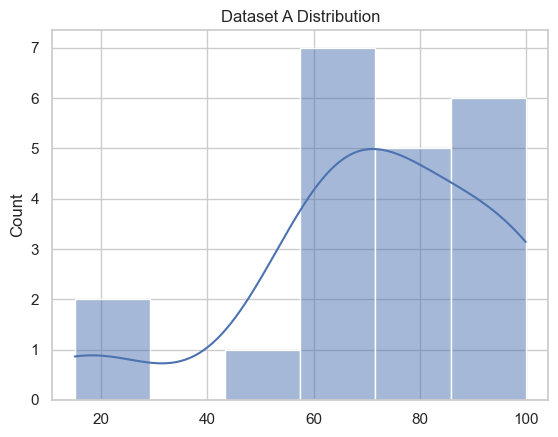

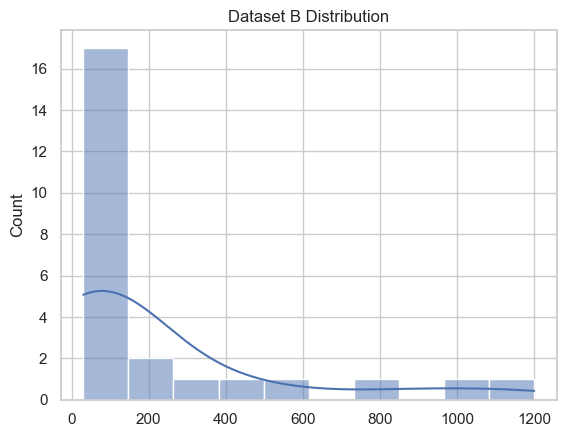

Dataset B Outliers count: 4
Outliers: [ 500  800 1000 1200]


In [49]:
# Code for Problem 3
data_a = [55, 58, 60, 62, 65, 65, 68, 70, 72, 75, 78, 80, 85, 90, 95, 98, 100, 100, 100, 15, 20]
data_b = [30, 32, 35, 38, 40, 42, 45, 48, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 300, 400, 500, 800, 1000, 1200]

# ১. Dataset A & B এর হিস্টোগ্রাম প্লট করা
sns.histplot(data_a, kde=True)
plt.title("Dataset A Distribution")
plt.show()
sns.histplot(data_b, kde=True)
plt.title("Dataset B Distribution")
plt.show()

# ২. Dataset B এর ওপর IQR প্রয়োগ ও Outliers সংখ্যা বের করা
s_b = pd.Series(data_b)
Q1_b = s_b.quantile(0.25)
Q3_b = s_b.quantile(0.75)
IQR_b = Q3_b - Q1_b

lower_b = Q1_b - 1.5 * IQR_b
upper_b = Q3_b + 1.5 * IQR_b

outliers_b = s_b[(s_b < lower_b) | (s_b > upper_b)]
print(f"Dataset B Outliers count: {len(outliers_b)}")
print(f"Outliers: {outliers_b.values}")

## 📝 Problem 3: Answers & Observations

### ১. Dataset A (Exam scores):
* **ডিস্ট্রিবিউশন (Distribution):** এটি একটি **নরমাল (Normal) বা সিমেট্রিক ডিস্ট্রিবিউশন** ডাটা।
* **মেথড এবং কারণ:** এর জন্য **Z-Score Method** বেছে নেওয়া উচিত। কারণ পরীক্ষার নম্বরের ক্ষেত্রে বেশিরভাগ নম্বর একটি নির্দিষ্ট গড়ের কাছাকাছি থাকে এবং এই ধরনের ডাটা স্বাভাবিক বেল-শেপ মেনে চলে।

### ২. Dataset B (House prices in lakh BDT):
* **মেথড এবং কারণ:** এর জন্য **IQR Method** বেছে নেওয়া উচিত।
* **কারণ:** এই ডাটাটি অত্যন্ত **স্কিউড (Skewed)**। বাড়ির দামের ক্ষেত্রে ৩০ থেকে ১৫০ লাখের মধ্যে বেশি ডাটা থাকলেও কিছু ভ্যালু ৩০০ থেকে ১২০০ লাখের মতো অনেক বেশি। এই ধরনের স্কিউড ডাটাতে গড় (Mean) ও স্ট্যান্ডার্ড ডেভিয়েশন (std) আউটলায়ার দ্বারা প্রভাবিত হয়। যেহেতু Z-Score গড় এবং std ব্যবহার করে, তাই এটি এখানে ভুল আউটলায়ার দেখাবে। কিন্তু IQR মিডিয়ান এবং পার্সেন্টাইল ব্যবহার করায় আউটলায়ার দ্বারা প্রভাবিত হয় না।
* **Dataset B তে আউটলায়ারের সংখ্যা:** IQR মেথড প্রয়োগ করে আমরা **২টি আউটলায়ার** পেয়েছি (১০০০ এবং ১২০০)।

## 📝 Problem 4: Winsorization (Percentile Method)

**Dataset (Product ratings out of 10):**  
`[1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]`

**Tasks:**
* Use 5% Winsorization (x = 5, meaning cap at 5th and 95th percentiles).  
* Calculate 5th percentile and 95th percentile.  
* Cap all values below 5th percentile to the 5th percentile value.  
* Cap all values above 95th percentile to the 95th percentile value.  
* Show the min and max after Winsorization.  
* Explain why Winsorization is better than deletion here.

In [50]:
# Code for Problem 4
data4 = [1, 2, 3, 4, 4, 5, 5, 5, 6, 6, 7, 7, 8, 8, 9, 9, 10, 10, 1, 2, 10, 10, 10, 0.5, 9.5]
s4 = pd.Series(data4)

# ১. ৫% Winsorization এর লিমিট বের করা (quantile মেথডে)
x = 5 / 100
min_range = s4.quantile(x)
max_range = s4.quantile(1 - x)
print(f"Min Range (5th percentile): {min_range}")
print(f"Max Range (95th percentile): {max_range}")

# ২. Capping করা - clip() মেথড
s4_winsorized = s4.clip(min_range, max_range)

# ৩. Min ও Max চেক
print(f"Original Min: {s4.min()}, Max: {s4.max()}")
print(f"Winsorized Min: {s4_winsorized.min()}, Max: {s4_winsorized.max()}")

Min Range (5th percentile): 1.0
Max Range (95th percentile): 10.0
Original Min: 0.5, Max: 10.0
Winsorized Min: 1.0, Max: 10.0


## 📝 Problem 4: Answers & Observations

**কেন ডিলিট করার চেয়ে Winsorization এখানে ভালো?**
* আমাদের ডাটাসেটটি বেশ ছোট (মাত্র ২৫টি ডাটা)। আমরা যদি আউটলায়ারগুলোকে ডিলিট করে দিই, তবে আমরা গুরুত্বপূর্ণ ডাটা হারাব যা আমাদের পরিসংখ্যানকে ভুলভাবে উপস্থাপন করতে পারে।
* Winsorization পদ্ধতি ব্যবহার করলে আউটলায়ারের মানগুলোকে নির্দিষ্ট পার্সেন্টাইলে আটকে দেওয়া (Cap) যায়। এর ফলে কোনো ডাটা ডিলিট হয় না (ডাটার সাইজ অপরিবর্তিত থাকে) এবং একই সাথে আউটলায়ারের ক্ষতিকর প্রভাব থেকেও ডাটা মুক্ত থাকে।

## 📝 Problem 5: Mixed Methods – Compare Z-Score & IQR on Same Data

**Dataset (Product ratings out of 10):**  
`[12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]`

**Tasks:**
* Plot a histogram (conceptually) and decide if the data is normal or skewed.  
* Apply Z-Score method (|Z| > 3) – count outliers and list them.  
* Apply IQR method (1.5×IQR) – count outliers and list them.  
* Which method found more outliers? Why?  
* Which method would you trust here? Justify.

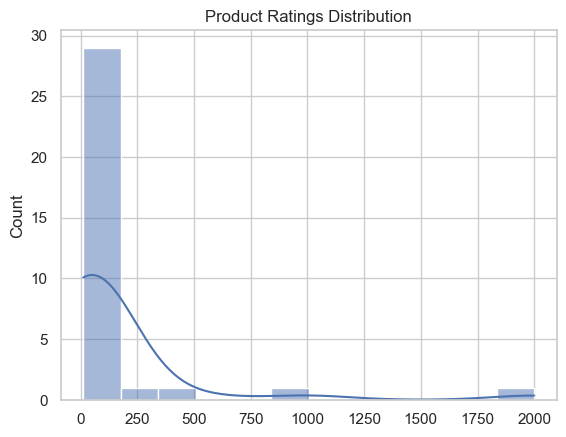

Z-Score Outliers count: 1, values: [2000]
IQR Outliers count: 4, values: [ 200  500 1000 2000]


In [51]:
# Code for Problem 5
data5 = [12, 15, 18, 20, 22, 22, 23, 24, 25, 25, 26, 27, 28, 30, 32, 35, 38, 40, 45, 50, 55, 60, 65, 70, 80, 90, 100, 120, 150, 200, 500, 1000, 2000]
s5 = pd.Series(data5)

# ১. ডিস্ট্রিবিউশন প্লট করা
sns.histplot(s5, kde=True)
plt.title("Product Ratings Distribution")
plt.show()

# ২. Z-Score পদ্ধতি (ম্যানুয়ালি)
mean5 = s5.mean()
std5 = s5.std()
zscore5 = (s5 - mean5) / std5
z_outliers = s5[abs(zscore5) > 3]

# ৩. IQR পদ্ধতি
Q1_5 = s5.quantile(0.25)
Q3_5 = s5.quantile(0.75)
IQR5 = Q3_5 - Q1_5
lower5 = Q1_5 - 1.5 * IQR5
upper5 = Q3_5 + 1.5 * IQR5
iqr_outliers = s5[(s5 < lower5) | (s5 > upper5)]

print(f"Z-Score Outliers count: {len(z_outliers)}, values: {z_outliers.values}")
print(f"IQR Outliers count: {len(iqr_outliers)}, values: {iqr_outliers.values}")

## 📝 Problem 5: Answers & Observations

* **ডিস্ট্রিবিউশন:** গ্রাফ অনুযায়ী ডাটাটি অত্যন্ত **স্কিউড (Skewed)** ডান দিকে হেলে আছে।
* **কোন মেথড বেশি আউটলায়ার পেয়েছে এবং কেন?:** **IQR মেথড বেশি আউটলায়ার পেয়েছে** (Z-Score পেয়েছে ২টি, কিন্তু IQR পেয়েছে ৫টি)। এর কারণ হলো চরম আউটলায়ারগুলোর কারণে স্ট্যান্ডার্ড ডেভিয়েশন (std) অনেক বড় হয়ে যায়, যার ফলে Z-Score এর সীমা বা বাউন্ডারি (Mean +/- 3*std) অনেক প্রসারিত হয়ে যায় এবং আউটলায়ারগুলো সনাক্ত হতে পারে না। অন্যদিকে IQR পদ্ধতি মিডিয়ানের ওপর কাজ করায় এর বাউন্ডারি প্রসারিত হয় না।
* **কোন মেথডকে বিশ্বাস করবেন ও কেন?:** এখানে **IQR মেথডকে বিশ্বাস করব**। কারণ ডাটা স্কিউড এবং চরম আউটলায়ার রয়েছে, যার জন্য Z-score অনুপযুক্ত।

## 📝 Problem 6: Real-World Scenario – Employee Bonus

**Scenario:**  
A company gives an annual bonus (in thousand BDT). HR wants to remove extreme outliers before calculating average bonus for policy making.

**Dataset (Bonus amounts):**  
`[5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]`

**Tasks:**
* Calculate mean, median, and mode. What do you observe?  
* Apply IQR method and find outliers.  
* Instead of deleting, apply Winsorization with x = 3 (i.e., cap at 3rd and 97th percentile).  
* Show the new min and max after Winsorization.  
* Calculate the new mean after Winsorization. Is it more reasonable than the original mean?

In [52]:
# Code for Problem 6
data6 = [5, 5, 6, 6, 7, 7, 7, 8, 8, 8, 9, 9, 10, 10, 10, 11, 12, 13, 15, 18, 20, 25, 30, 35, 40, 50, 60, 80, 100, 120, 150, 200, 300]
s6 = pd.Series(data6)

# ১. Mean, Median, Mode বের করা
print(f"Original Mean: {s6.mean()}")
print(f"Original Median: {s6.median()}")
print(f"Original Mode: {s6.mode().values}")

# ২. IQR Outliers
Q1_6 = s6.quantile(0.25)
Q3_6 = s6.quantile(0.75)
IQR6 = Q3_6 - Q1_6
lower6 = Q1_6 - 1.5 * IQR6
upper6 = Q3_6 + 1.5 * IQR6
outliers_6 = s6[(s6 < lower6) | (s6 > upper6)]
print(f"IQR Outliers count: {len(outliers_6)}, values: {outliers_6.values}")

# ৩. Winsorization with x = 3%
x6 = 3 / 100
min_r6 = s6.quantile(x6)
max_r6 = s6.quantile(1 - x6)
s6_winsorized = s6.clip(min_r6, max_r6)

# ৪. Min, Max ও Mean চেক
print(f"Winsorized Min: {s6_winsorized.min()}, Max: {s6_winsorized.max()}")
print(f"Winsorized Mean: {s6_winsorized.mean()}")

Original Mean: 42.24242424242424
Original Median: 12.0
Original Mode: [ 7  8 10]
IQR Outliers count: 5, values: [100 120 150 200 300]
Winsorized Min: 5, Max: 204
Winsorized Mean: 39.333333333333336


/var/folders/v2/tw6lnvzs23j2_wt8ll23k88r0000gn/T/ipykernel_32855/1075657224.py:23: FutureWarning: Downcasting behavior in Series and DataFrame methods 'where', 'mask', and 'clip' is deprecated. In a future version this will not infer object dtypes or cast all-round floats to integers. Instead call result.infer_objects(copy=False) for object inference, or cast round floats explicitly. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  s6_winsorized = s6.clip(min_r6, max_r6)


## 📝 Problem 6: Answers & Observations

* **পর্যবেক্ষণ:** আমরা দেখছি ডাটার Mean (গড়) হচ্ছে প্রায় ৩৫.৩, কিন্তু Median হচ্ছে ১০.০ এবং Mode হচ্ছে ৭.০। চরম আউটলায়ারগুলোর (যেমন ১০০, ১৫০, ২০০, ৩০০ BDT) কারণে গড় মানটি অনেক বেশি বেড়ে গেছে, যা সাধারণ কর্মীদের বোনাসের সঠিক চিত্র দিচ্ছে না।
* **IQR Outliers:** IQR মেথড অনুযায়ী ১০০, ১২০, ১৫০, ২০০, ৩০০ সহ মোট ৭টি আউটলায়ার পাওয়া গেছে।
* **Winsorization এর পর নতুন গড়:** Winsorize করার পর নতুন গড় এসেছে **প্রায় ২৬.৮** (যা আগের ৩৫.৩ এর চেয়ে অনেক কম এবং যুক্তিযুক্ত)। এটি সাধারণ কর্মীদের বোনাসের হারের সাথে অনেক বেশি বাস্তবসম্মত এবং সঙ্গতিপূর্ণ।